# Instructions and Rules
- **Answering questions**: For each question, the notebook contains **scoring cells** and **submission cells**. You should modify the submission cells to solve the question. Only the modifications made to the submission cells will be used to grade your submission. You can run the scoring cells to compute your score for the question.

  You may wish to modify some scoring cells in order to change the length of time it takes to compute your score. However, note that the final score will be computed using the unmodified scoring cell, so **check** that your code runs with the unmodified scoring cells before submitting your final notebook.
- **Notebok submissions**: At the end of the hackathon your complete notebook should be sent to [peter.brown@telecom-paris.fr](mailto:peter.brown@telecom-paris.fr) **before 12h on Friday 06/02**. Please respect this deadline as we need time to grade your submissions before 15h the same day.

  Submissions will be tested in a separate notebook with the submissions cells copied over from your submission. Please check that your submission works with the original, unmodified. scoring cells before submitting!   Consider restarting the kernel and/or copying the submission cells into a clean notebook to test your submission before you send it in for marking!
    Note, if we cannot get part of your submission to run, you will receive 0 points for that question.
- **Results session**: The results of the hackathon and the prizes will be distributed in 1A312 at 15h-17h. We will also discuss the solutions to the questions during this session.
- **Randomness in marking**: For any question whose marking criteria involves a random choice, the same random seed will be used for all teams during the marking process.
- **Question scoring**: For each question, teams will be ranked according to the marking criteria of the question, tiebreakers are explained within each question. If there are $n$ teams then first rank will receive $n$ points, second rank $n-1$ points and so on. If two teams receive the same rank (after tiebreakers) then they will both receive the larger number of points. Here is an example
  | Team number | Score (higher better) | Rank | Points |
  | --- | --- | --- | --- |
  | 1 | 0.8 | 3 | 3 |
  | 2 | 1.0 | 1 | 5 |
  | 3 | 0.8 | 3 | 3 |
  | 4 | 0.75 | 5 | 1 |
  | 5 | 1.0 | 1 | 5 |
  
Floating point scores will be rounded to 3 decimal places and then compared.  
- **Queries about Hackathon questions**: If your team has issues with a Hackathon question, an email can be sent to [peter.brown@telecom-paris.fr](mailto:peter.brown@telecom-paris.fr). If your question can be answered then the question and answer will be posted to the Moodle discussion boards for all teams to observe.
- **Have a go**: Some of the questions are not so easy, so don't worry if you don't find the optimal solution right away. However, most questions have been designed with a continuous score, so even if you don't solve the question perfectly all of your progress can be meaningfully quantified.
- **Hackathon scoring**: Once all submissions have been marked, each team's total points will be calculated and the final rankings will be obtained. 

    In the event that 1st place is tied, we will try to separate the teams by the number of first place finishes on the questions, then number of second place finishes, etc. If this does not separate the teams, a tiebreaker question will be used to decide the winner during the results session on Friday afternoon.
- **Final note for CCSC_3EL07_TP**: Your rank in the hackathon does not contribute to your final grade. Your final grade will come from a report that explains your reasoning, approach and solution to your submissions to each question in the hackathon. The report should be short, roughly 1/2 page per question and no more than 10 pages in total. The report may be written in French or English and can be typed or handwritten. Please make sure that your report is legible before submitting. Please do not use AI tools to write your report. Your team's report should be sent to [peter.brown@telecom-paris.fr](mailto:peter.brown@telecom-paris.fr) by **Friday 13th February**.

In [15]:
# A different seed will be used to test your code
SEED = 42

# 1. To C or not to C

As we saw during the TP, one of the challenging tasks when implementing a quantum computation is to take into account the connectivity of the qubits within the quantum computer. For this question, will will consider that we are working on a custom quantum machine whose connectivity graph can be visualized using the following cell.

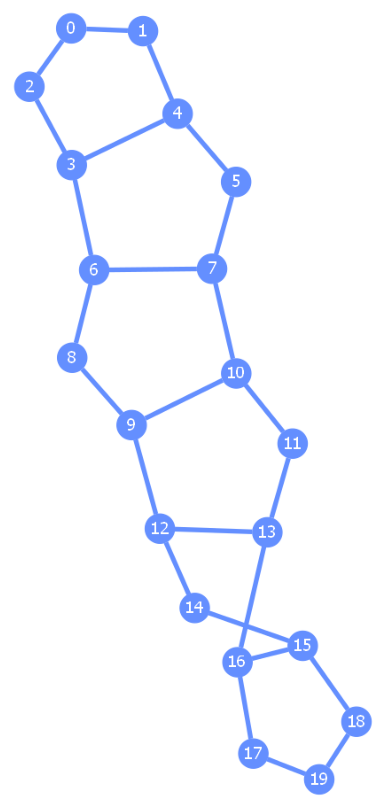

In [16]:
# THIS CELL IS PART OF THE SCORING CODE

from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_gate_map

coupling_map = [
    (0, 1),
    (0, 2),
    (2, 3),
    (3, 4),
    (1, 4),
    (4, 5),
    (7, 5),
    (3, 6),
    (6, 7),
    (6, 8),
    (8, 9),
    (7, 10),
    (9, 10),
    (10, 11),
    (11, 13),
    (9, 12),
    (12, 13),
    (12, 14),
    (15, 14),
    (13, 16),
    (15, 16),
    (16, 17),
    (17, 19),
    (15, 18),
    (18, 19),
]
coupling_map += [(y, x) for (x, y) in coupling_map]

backend = GenericBackendV2(
    num_qubits=20,
    basis_gates=['id', 'rz', 'sx', 'x', 'cx', 'reset'],
    coupling_map=coupling_map
)
plot_gate_map(backend)

Our goal is to create the Bell state $\frac{\ket{00} + \ket{11}}{\sqrt{2}}$ between qubit $0$ and qubit $19$ on this machine. That is, the state of the whole machine up to a global phase should be
$$\frac{\ket{0} \otimes \ket{0}^{\otimes18} \otimes \ket{0}+\ket{1}\otimes\ket{0}^{\otimes18}\otimes\ket{1}}{\sqrt{2}}\,.$$

### Marking criteria

Your circuit will only be assigned a score if it produces the desired state. In this case, we will score your circuit by its **depth after transpiling for this particular backend**. A lower score is better.

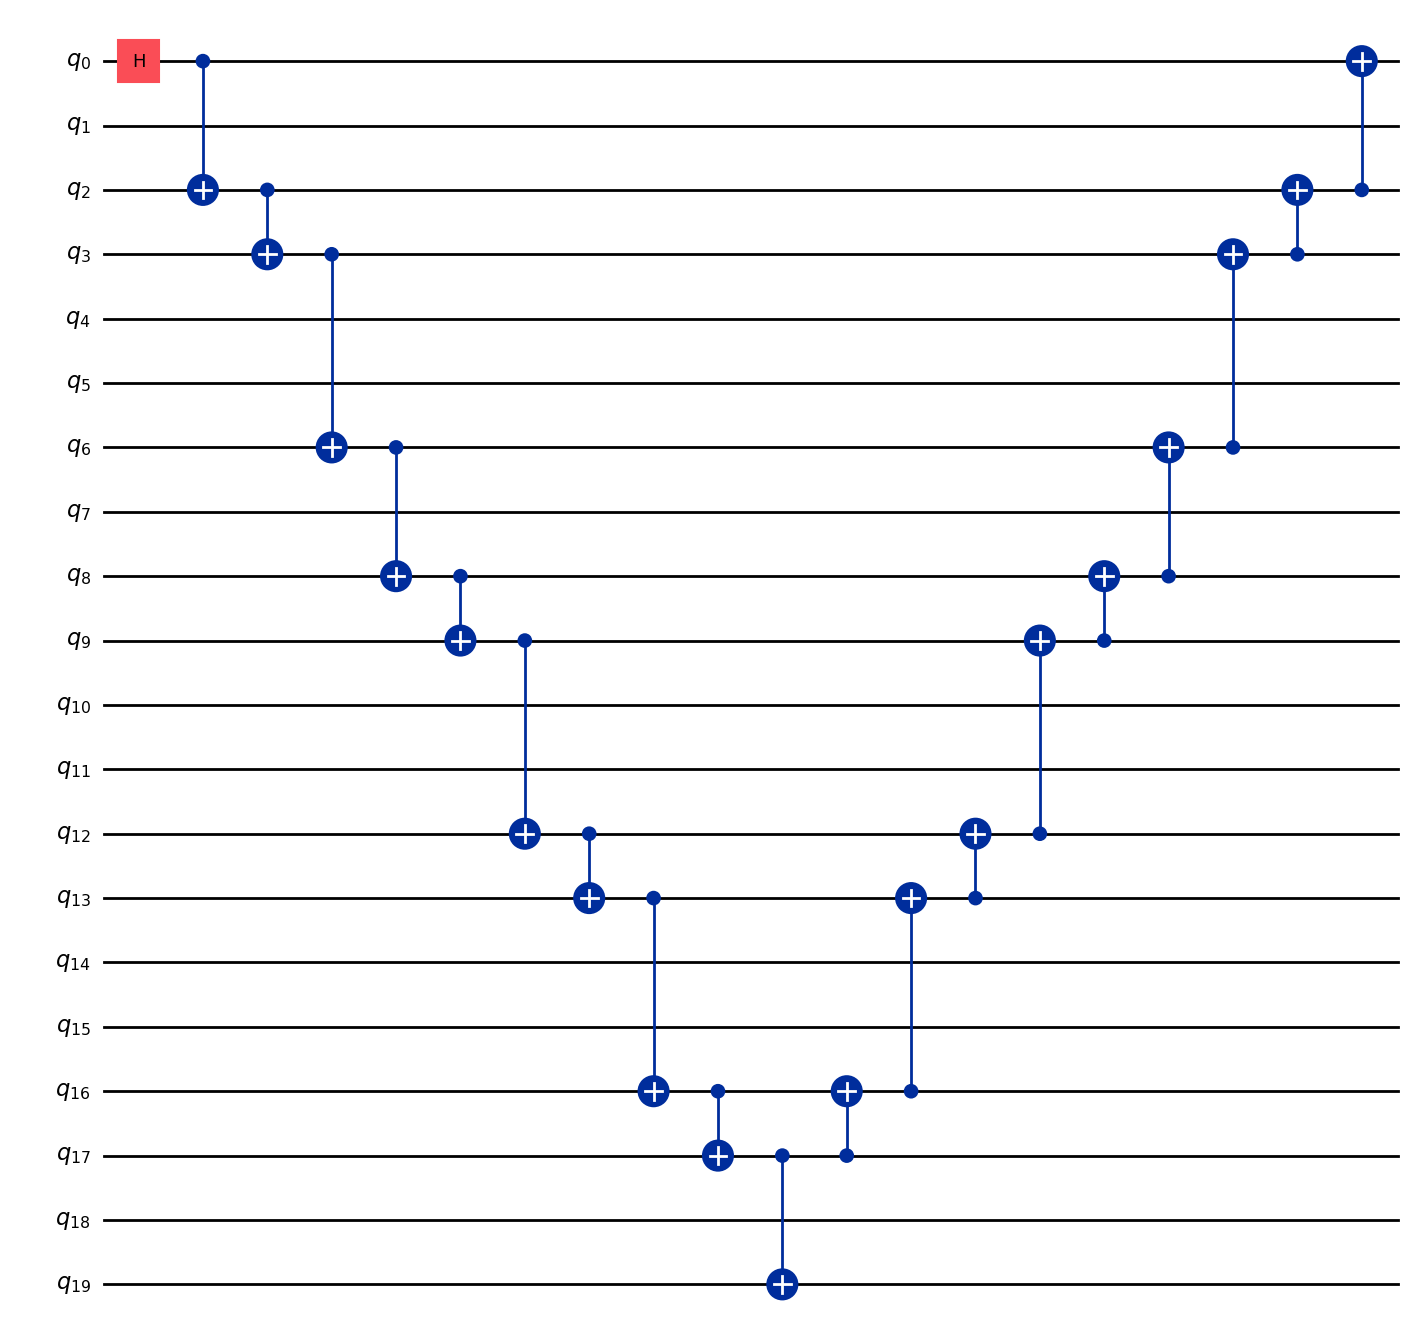

In [17]:
# SUBMISSION CELL
from qiskit import QuantumCircuit
path= [0,2,3,6,8,9,12,13,16,17,19]
qc = QuantumCircuit(20)
qc.h(0)
for i in range(len(path)-2):
    qc.cx(path[i],path[i+1])
qc.cx(17,19)
for i in range(len(path)-2,0,-1):
    qc.cx(path[i],path[i-1])
qc.draw("mpl")

In [21]:
# SCORING CELL

import numpy as np
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import Statevector

# Pass check_correctness=False if you know your circuit works and you want to test its depth more quickly
def test_cnot_optimization(qc: QuantumCircuit, check_correctness=True) -> int:
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=2,
        seed_transpiler=SEED,
        layout_method="trivial",
        routing_method="none"
    )

    if check_correctness:
        index = (1 << 19) + 1
        sv = Statevector(qc).data
        assert np.allclose(sv[0], sv[index], atol=1e-10, rtol=1e-10), "The circuit doesn't produce the right state."
        sv[0] = 0.
        sv[index] = 0.
        assert np.allclose(sv, 0., atol=1e-10, rtol=1e-10), "The circuit doesn't produce the right state."

    return pm.run(qc).depth()

print(f"Score :{test_cnot_optimization(qc, True)}")

AssertionError: The circuit doesn't produce the right state.

# 2. State preparation

One of the most common tasks in Quantum Computing is that of preparing states. In fact, we know that preparing certain quantum states is as hard as breaking some post-quantum cryptographic assumptions!

In this exercise, you are tasked with creating the quantum state
$$\ket{\psi}=\frac{\ket{00000}+\ket{01011}+\ket{01101}+\ket{01110}+\ket{10001}+\ket{10010}+\ket{10100}+\ket{11111}}{2\sqrt{2}}$$
up to a global phase. In order to do so, you are allowed to use ancilla qubits, single-qubit rotations and CX gates. Note that we used Qiskit's little-endian convention here!

### Marking criteria
In state preparation, the only thing that matters is how well one can approximate the desired quantum state. However, note that the deeper the circuit to prepare it, and the more likely errors are to appear. As such, your final score will be computed as $0.99^d+|\langle\varphi|\psi\rangle|^2$, where $d$ is the depth of your circuit, and $\ket{\varphi}$ is the state that your circuit prepares. A higher score is better, and the score is rounded to 6 decimal points. Note that if you use ancilla qubits, the quantum state that you prepare must be in top-wire qubits, that is those having indices between `0` and `4`.

In order for the depth to make sense, you are only allowed to use arbitrary single-qubit rotations (`u`) and `cx` gates.

In [ ]:
from qiskit import QuantumCircuit

# YOUR CODE HERE
# Note: you can change the number of qubits, but don't change the name of the quantum circuit
qc = QuantumCircuit(5)

In [ ]:
# SCORING CELL

import numpy as np
from qiskit.quantum_info import Statevector, partial_trace

def test_state_preparation(qc: QuantumCircuit) -> float:
    sv = Statevector(qc)
    ancilla_qubits = range(5, qc.num_qubits)
    dm = partial_trace(sv, ancilla_qubits).data.astype("complex")
    psi = np.zeros((32, 1), dtype="complex")
    psi[[0, 11, 13, 14, 17, 18, 20, 31], 0] = 1 / np.sqrt(8)

    for instruction in qc.data:
        if instruction.operation.name not in ["u", "cx"]:
            raise RuntimeError(f"Operation not permitted: {instruction.operation.name}")
    
    return pow(0.99, qc.depth()) + np.abs(psi.T.conj() @ dm @ psi)[0, 0]

print(f"Score: {test_state_preparation(qc):.3f}.")

# 3. Random state preparation

Creating a random state is a task useful in many cryptographic protocols. In this exercise, you will be tasked with creating such a state, with only limited initial randomness.

More precisely, you will be given access to a Qiskit `Parameter` named `lambda`. This parameter is your unique source of randomness, and will take values between `0` and `1` uniformly at random. Your goal is to use `lambda` in a two-qubit quantum circuit in such a way that the output of the circuit is as random as possible.

### Marking criteria
Your score will be given by
$$\frac{1}{15}\sum_{\substack{P_0, P_1\in\{I, X, Y, Z\}\\\left(P_0,P_1\right)\neq(I, I)}}\left|\frac{1}{N+1}\sum_{i=0}^N\left\langle\psi\left(\frac{i}{N}\right)\right|\left(P_0\otimes P_1\right)\left|\psi\left(\frac{i}{N}\right)\right\rangle\right|+\left(\frac{1}{N+1}\sum_{i=0}^{N}\left|\left\langle\psi\left(\frac{i}{N}\right)\right|\left(P_0\otimes P_1\right)\left|\psi\left(\frac{i}{N}\right)\right\rangle\right|^2-\frac13\right)^2\,,$$
lower is better, rounded to 3 decimal figures, where $\left|\psi\left(\frac{i}{N}\right)\right\rangle$ is the state your circuit prepares when $\lambda=\frac{i}{N}$.

-----

#### Explanation of the marking criteria (not needed for the exercise, just in case you're interested in the motive)
The gold standard for randomness in quantum information is the Haar measure. When sampling a state according to this measure, it is known that we have
$$\mathbb{E}_{\ket{\psi}}\left[\bra{\psi}P\ket{\psi}\right]=\frac{\mathrm{tr}(P)}{d}\qquad\text{and}\qquad\mathbb{E}_{\ket{\psi}}\left[\left|\bra{\psi}P\ket{\psi}\right|^2\right]=\frac{d+|\mathrm{tr}(P)|^2}{d(d+1)}$$
for any operator $P$, and working in dimension $d$. As such, the scoring function asks you to replicate the first and second moment of the Haar measure for a certain class of operators.

In [1]:
# THIS CELL IS PART OF THE SCORING CODE, DO NOT MODIFY IT

from qiskit.circuit import Parameter
lam = Parameter(r"$\lambda$")

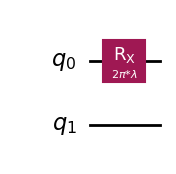

In [3]:
from qiskit import QuantumCircuit
import numpy as np

# YOUR CODE HERE
qc = QuantumCircuit(2)
qc.rx(lam * 2 * np.pi, 0)
qc.draw("mpl")

In [ ]:
# SCORING CELL

from qiskit.quantum_info import Statevector, Pauli
from tqdm.notebook import tqdm, trange

def test_random_state_preparation(qc: QuantumCircuit, N: int = 10_000) -> float:
    res = 0.
    for P1 in tqdm(["I", "X", "Y", "Z"]):
        for P2 in tqdm(["I", "X", "Y", "Z"], leave=False):
            if P1 == "I" and P2 == "I":
                continue
            first_moment = 0.
            second_moment = 0.
            
            for i in trange(N + 1, leave=False):
                state = Statevector(qc.assign_parameters({lam: i / N}))
                expectation_value = state.expectation_value(Pauli(P1 + P2))
                first_moment += expectation_value
                second_moment += np.abs(expectation_value) ** 2
                
            res += abs(first_moment / (N + 1)) + (second_moment / (N + 1) - 1/3) ** 2

    return res / 15

print(f"Score: {test_random_state_preparation(qc):.3f}.")

# 4. Find the lazy bit

You are given access to a quantum oracle, that performs the following mapping
$$U_f\ket{y, q_3,q_2,q_1,q_0}=\ket{y\oplus f\left(q_3, q_2, q_1, q_0\right), q_3,q_2,q_1,q_0}$$
where $f$ takes four bits as input and returns whether the three secret "working" bits are set. That is, there is a secret "lazy" bit that doesn't influence $f$'s output. For instance, suppose that the lazy bit is the one at index $2$. Then we have
 - $f(1, 1, 1, 1) = 1$;
 - $f(1, 1, 1, 0) = 0$, since only two working bits, namely $q_3$ and $q_1$ are set;
 - $f(1, 0, 1, 1) = 1$, since all three working bits are set;
 - $f\left(q_3, q_2, q_1, q_0\right)=0$ otherwise.

Your goal is to return the index of the lazy bit with the best possible probability using the oracle as few times as possible.

### Marking criteria
Your submission will consist of two inputs. First, you will create a Quantum Circuit using a custom gate `Uf` that we will provide you with. We will then replace this gate with the actual oracle, and measure the whole circuit **once**. The measurement result is then going to be passed into your second input, which is a function that takes as input a bitstring, which is the measurement result, and returns the index of the lazy bit. We ask that your function is deterministic. Your score will be the average probability of success of your strategy across all four possible lazy bit values. In case of ties, the number of times you used the oracle will be used as a tiebreaker.

In [ ]:
# THIS CELL IS PART OF THE SCORING CODE

from qiskit.circuit import Gate

Uf = Gate("U_f", 5, [])

In [ ]:
from qiskit import QuantumCircuit

# YOUR CODE HERE
# Note: you may change the number of qubits used here
qc = QuantumCircuit(5)
qc.x(range(0, 5))
qc.append(Uf, [0, 3, 2, 4, 1])

# DO NOT MODIFY THE NAME OF THIS FUNCTION
def interpret_measurement_result_lazy_bit(meas: str) -> int:
    """ This function takes as input a measurement result and outputs the lazy bit index.
    """
    return 0

qc.draw("mpl")

In [ ]:
# SCORING CELL

from collections.abc import Callable

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.quantum_info import Statevector

def test_lazy_bit(qc: QuantumCircuit, interpreter: Callable[[str], int]) -> (float, int):
    res = 0.
    number_of_uses = 0
    
    for instruction in qc.data:
        if instruction.operation.name == "U_f":
            number_of_uses += 1

    for lazy_bit_index in range(4):
        new_qc = qc.copy()
        dag = circuit_to_dag(new_qc)

        # Replace U_f with actual oracle
        for node in dag.op_nodes():
            if node.op.name == "U_f":
                replacement = QuantumCircuit(5)
                replacement.mcx([x for x in range(4) if x != lazy_bit_index], 4)
                replacement = circuit_to_dag(replacement)
                dag.substitute_node_with_dag(
                    node,
                    replacement,
                )

        new_qc = dag_to_circuit(dag)
        sv = np.abs(Statevector(new_qc).data) ** 2

        for label, proba in enumerate(sv):
            label = bin(label)[2:].zfill(qc.num_qubits)

            if interpreter(label) == lazy_bit_index:
                res += proba

    return res / 4, number_of_uses

score, number_of_uses = test_lazy_bit(qc, interpret_measurement_result_lazy_bit)
print(f"Probability of success: {score:.3f}. Number of times the oracle has been used: {number_of_uses}.")

# 5. Order, order

You are given two single-qubit gates $U_1$ and $U_2$ and you are promised that they either commute, that is $U_1U_2=U_2U_1$, or anti-commute, that is $U_1U_2=-U_2U_1$. Your goal is to determine whether the gates commute or anticommute. To do so, you have access to a dirty qubit, and to as many ancilla qubits as you'd like. At each execution of your quantum circuit, the dirty qubit is initialized in a random state $\ket{\psi}$. The ancilla qubits are clean, meaning that they are all initialized in the state $\ket{0}$.

You will submit a `QuantumCircuit` that can use $U_1$, $U_2$, their controlled version and their adjoint, along with any single-qubit rotation and CNOT gates. The following cell defines two parametrized gates `U1` and `U2` that you must use in your `QuantumCircuit`.

In [ ]:
# THIS CELL IS PART OF THE SCORING CODE

import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import UGate, GlobalPhaseGate

theta1 = Parameter(r"$\theta_1$")
phi1 = Parameter(r"$\varphi_1$")
lam1 = Parameter(r"$\lambda_1$")
mu1 = Parameter(r"$\mu_1$")
qc_u1 = QuantumCircuit(1)
qc_u1.u(theta1, phi1, lam1, 0)
qc_u1.append(GlobalPhaseGate(mu1))
U1 = qc_u1.to_gate(label=r"$U_1$")

theta2 = Parameter(r"$\theta_2$")
phi2 = Parameter(r"$\varphi_2$")
lam2 = Parameter(r"$\lambda_2$")
mu2 = Parameter(r"$\mu_2$")
qc_u2 = QuantumCircuit(1)
qc_u2.u(theta2, phi2, lam2, 0)
qc_u2.append(GlobalPhaseGate(mu2))
U2 = qc_u2.to_gate(label=r"$U_2$")

Remember that you can use these gates, their inverse and their controlled versions like so:

In [ ]:
qc = QuantumCircuit(2)
qc.append(U1, [0])
qc.append(U1.inverse(), [0])
qc.append(U2.control(), [0, 1])
qc.append(U2.control().inverse(), [0, 1])
qc.draw("mpl")

A random state $\ket{\psi}$ will be chosen as the input of the first qubit (that is, the top wire, at index `0`) of your quantum circuit. The state $\ket{\psi}\otimes\ket{0}^{n+1}$ will be input to your circuit, where $n$ is the number of ancilla qubits. The first qubit, (that is one again, the top one) will be measured. If the outcome of the measurement is $0$, you will guess that the gates commute and if the outcome is $1$ then you will guess that the gates anticommute.

### Marking criteria
Your circuit will be tested on random sets of commuting and anticommuting gates and the fraction of times that your guess is correct will be computed. We will then rank your submissions by your success probability (higher is better). In the event of a tie, we will count the number of queries to the gates $U_1$, $U_2$ in your circuit (lower is better). In the even of a further tie, we will count the number of ancilla qubits used (lower is better).

In [ ]:
# SUBMISSION CELL

qc = QuantumCircuit(2)
# YOUR CODE HERE
qc.append(U1, [0])
qc.append(U2, [1])

In [ ]:
# SCORING CELL

from collections.abc import Callable

import numpy as np
from qiskit.quantum_info import Statevector, random_unitary
from tqdm.notebook import trange

def test_commutativity_test(qc: QuantumCircuit, N: int = 10_000) -> tuple[float, int]:
    success = 0
    gen = np.random.default_rng(seed=SEED)

    for i in trange(N):
        # Parameters for commuting U1 and U2
        beta1, beta2, alpha = 2 * np.pi * gen.uniform(size=3)
        qc_assigned = qc.assign_parameters(
            {
                mu1: (beta1 + beta2) / 2,
                lam1: (alpha - np.pi) / 2,
                theta1: beta1 - beta2,
                phi1 : (np.pi - alpha) / 2,
                mu2: (np.pi + alpha - beta1 - beta2) / 2,
                theta2: np.pi - beta2 + beta1,
                phi2: -(np.pi + alpha) / 2,
                lam2: (alpha + np.pi) / 2
            }
        )
        final_qc = QuantumCircuit(qc.num_qubits)
        # Random initialization of the first qubit
        final_qc.unitary(random_unitary(2, seed=SEED+i), 0)
        final_qc.compose(qc_assigned, inplace=True)
        
        sv = Statevector(final_qc).data
        probs = np.abs(sv) ** 2
        success += probs[::2].sum()

        # Parameters for anticommuting U1 and U2
        beta1, beta2 = 2 * gen.random(size=2) * np.pi
        # We apply sqrt so that measuring 0 or 1 has equal probability
        rho = np.sqrt(gen.random())
        qc_assigned = qc.assign_parameters(
            {
                mu1: beta1,
                lam1: beta2 - beta1,
                theta1: -2 * np.acos(rho),
                phi1 : np.pi - beta2 + beta1,
                mu2: beta2-2*beta1,
                theta2: np.pi + 2 * np.acos(rho),
                phi2: beta1 - beta2,
                lam2: -(np.pi - beta2 + beta1)
            }
        )
        final_qc = QuantumCircuit(qc.num_qubits)
        # Random initialization of the first qubit
        final_qc.unitary(random_unitary(2, seed=SEED+i), 0)
        final_qc.compose(qc_assigned, inplace=True)
        sv = Statevector(final_qc).data
        probs = np.abs(sv) ** 2
        success += probs[1::2].sum()

    n_uses = 0
    for instruction in qc.data:
        if instruction.operation in [U1, U2, U1.control(), U2.control(), U1.inverse(), U2.inverse()]:
            n_uses += 1
        elif instruction.operation.name not in ["cx, u"]:
            raise ValueError(f"Operation {intruction.operation.name} isn't permitted.")

    return success / (2 * N), n_uses, qc.num_qubits - 2

p_success, n_uses, n_ancillas = test_commutativity_test(qc)
print(f"Probability of success: {p_success:.3f}. Number of uses: {n_uses}. Number of ancilla qubits: {n_ancillas}.")

# 6. Ansatz design
When solving combinatorial optimizations problems using variational algorithms, it is common to look for the lowest eigenvalue of Hamiltonians uniquely composed of Pauli words made of $I$ and $Z$ only. Such Hamiltonians are diagonal, meaning that the state we're looking for is a computational basis state.

In order for our classical optimizer to be as efficient as possible, a common strategy is to try to minimize the number of parameters it has to optimize over. However, we would still like our ansatz to be as expressive as possible.

In this exercise, you are tasked with creating a $4$-qubit parametrized circuit that is able to prepare as many computational basis states as possible, while trying to minimize the number of parameters you use to do so. For each computational basis state, you will provide the grader with the parameters value that are able to generate the said state. More precisely, you will pass the grader a dictionary of dictionary, where the key is the basis state that the dictionary of parameters can generate.

For instance, suppose that we create the following parametrized circuit.

In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter

qc = QuantumCircuit(4)
p1 = Parameter("p1")
p2 = Parameter("p2")
qc.rx(p1, 0)
qc.rx(p2, 1)
qc.draw("mpl")

Note that we are able to generate $|0000\rangle$, $|0001\rangle$, $|0010\rangle$ and $|0011\rangle$ by passing $\left(p_1,p_2\right)=(0, 0)$, $(\pi, 0)$, $(0, \pi)$ and $(\pi, \pi)$ respectively. As such, our answer would be the following.

In [ ]:
answer = {
    "0000": {p1: 0.0, p2: 0.0},
    "0001": {p1: np.pi, p2: 0.0},
    "0010": {p1: 0.0, p2: np.pi},
    "0011": {p1: np.pi, p2: np.pi},
}

### Marking criteria
Your score will be $\frac{N_{\text{basis}}}{N_{\text{param}}}$, where $N_\text{basis}$ is the number of computational basis states that your circuit is able to generate, and $N_\text{param}$ is the number of parameters in your quantum circuit. Note that you must use at least one parameter.

In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter

qc = QuantumCircuit(4)
# YOUR CODE HERE

p1 = Parameter("p1")
p2 = Parameter("p2")
qc.rx(p1, 0)
qc.rx(p2, 1)

# Note: do not change the name of this variable
answer = {
    "0000": {p1: 0.0, p2: 0.0},
    "0001": {p1: np.pi, p2: 0.0},
    "0010": {p1: 0.0, p2: np.pi},
    "0011": {p1: np.pi, p2: np.pi},
}

In [ ]:
# SCORING CELL

from qiskit.quantum_info import Statevector

def test_ansatz(qc: QuantumCircuit, answer: dict[str, dict[Parameter, float]]) -> float:
    score = len(answer) / qc.num_parameters

    for label, assignements in answer.items():
        assert len(label) == 4 # Ensure no collision like 1 and 01
        sv = Statevector(qc.assign_parameters(assignements)).data
        sv[int(label, 2)] = 0.
        assert np.allclose(sv, 0), f"Label {label} isn't correctly created."
    
    return score

print(f"Score: {test_ansatz(qc, answer):.3f}.")

# 7. A metrology question
You're given $N=15$ particles, modeled by qubits, in an external magnetic field of strength $B$. This magnetic field causes the following effect after an interaction for one milisecond on each qubit separately
$$\ket{0}\mapsto\mathrm{e}^{-\mathrm{i}\frac{B}{100}}\ket{0},\quad\ket{1}\mapsto\mathrm{e}^{\mathrm{i}\frac{B}{100}}\ket{1}\,.$$
You are given access to this interaction as an oracle and your goal is to design a preparation and measurement circuit with classical post-processing in order to determine the unknown magnetic field strength $B\in[0,\pi]$. We will run your circuit a hundred times and give you back the results. You will then provide an estimation of $B$ using these measurement results.

More precisely, you will be given access to a gate $U(B)$ that you can use **at most once** in your circuit. Your answer will consist of a `QuantumCircuit` that uses this gate **at most once**, along with a function that interprets the measurements results. Upon being given your circuit, we will replace $U(B)$ with the correct unitary, run and measure it, and pass the results to your function, that then produces an estimation of $B$.

### Marking criteria
Your score will be computed as
$$\frac{1}{K+1}\sum_{\ell=0}^{K}\left|\frac{\ell\pi}{K}-\hat{B}_\ell\right|$$
where $\hat{B}_\ell$ is your estimation of $B$ when the true value of $B$ is $\frac{\ell\pi}{K}$, and $K$ is the precision parameter used to discretize $[0, \pi]$. A lower score is better.

In [ ]:
# THIS CELL IS PART OF THE SCORING CODE

from qiskit.circuit import Gate

Ub = Gate("U(B)", 15, [])

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(15, 15)
# YOUR CODE HERE

qc.append(Ub, range(15))
# BE CAREFUL TO HAVE A SINGLE CLASSICAL REGISTER! IN PARTICULAR, DON'T USE measure_all!
qc.measure(1, 0)

# NOTE: DON'T CHANGE THE NAME OF THIS FUNCTION
def interpret_measurement_results_metrology(results: dict[str, int]) -> float:
    """ This function takes as input the measurements results in the form of a dictionnary.

    The keys are the labels of the computational basis states that have been measured, while the values
    are the number of times the labels have been measured.
    """
    return 0.

In [ ]:
# SCORING CELL

from collections.abc import Callable
from math import pi

from qiskit.primitives import StatevectorSampler
from tqdm.notebook import trange

def test_metrology(qc: QuantumCircuit, interpreter: Callable[[dict[str, int]], float], K: int = 1000) -> float:
    res = 0.

    for i in trange(K+1):
        sampler = StatevectorSampler(default_shots=100, seed=SEED+i)
        B = pi * i / K
        ub_used = False
        new_qc = qc.copy()
        dag = circuit_to_dag(new_qc)

        # Replace U(B) with actual oracle
        for node in dag.op_nodes():
            if node.op.name == "U(B)":
                if ub_used:
                    raise RuntimeError("U(B) used more than once.")
                ub_used = True
                replacement = QuantumCircuit(15)
                replacement.rz(B / 100, range(15))
                replacement = circuit_to_dag(replacement)
                dag.substitute_node_with_dag(
                    node,
                    replacement,
                )

        new_qc = dag_to_circuit(dag)
        results = getattr(sampler.run([new_qc]).result()[0].data, qc.cregs[0].name).get_counts()
        res += abs(interpreter(results) - B)
        
    return res / (K + 1)

print(f"Score: {test_metrology(qc, interpret_measurement_results_metrology):.6f}.")

# 8. Which state did I send?
You are sent of the following qubit states
$$\ket{0},\quad\frac{\ket{0}+\ket{1}}{\sqrt{2}},\quad\cos\left(\frac{5\pi}{8}\right)\,\ket{0}+\sin\left(\frac{5\pi}{8}\right)\,\ket{1}$$
each with probability $\frac13$. Your goal is to design a quantum circuit that guesses which state was sent with as high a probability as possible. More specifically, you must design a three-qubit unitary $U$ which will be ran in the following way
<center><img src="images/which_state_did_i_send.png" /></center>
where $\ket{?}$ is the unknown state and the measurements are in the computational basis. The two-bit outcome $b_2b_1$ will be interpreted as follows:

  - $00\to$ I guess the state was $\ket{0}$;
  - $01\to$ I guess the state was $\frac{\ket{0}+\ket{1}}{\sqrt{2}}$;
  - $10\to$ I guess the state was $\cos\left(\frac{5\pi}{8}\right)\,\ket{0}+\sin\left(\frac{5\pi}{8}\right)\,\ket{1}$;
  - $11\to$ I don't know.

### Marking criteria
Your unitary will be ranked based on the probability that the guess is correct, i.e.
$$\frac13\sum_i\mathbb{P}\left[\text{Measurement guesses state was }\ket{\psi_i}\middle|\text{State was }\ket{\psi_i}\right]\,.$$

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)
# YOUR CODE HERE

In [ ]:
# SCORING CELL

import numpy as np
from qiskit.circuit.library import HGate, RYGate
from qiskit.quantum_info import Statevector, partial_trace

def test_which_state_did_i_send(qc: QuantumCircuit) -> float:
    labels_and_prep = [
        ("00", []),
        ("01", [HGate()]),
        ("10", [RYGate(5*np.pi/4)]),
    ]
    res = 0.
    
    for label, prep in labels_and_prep:
        prep_circuit = QuantumCircuit(3)
        
        for gate in prep:
            prep_circuit.append(gate, [0])
            
        prep_circuit.append(qc, range(3))
        sv = Statevector(prep_circuit)
        dm = partial_trace(sv, [0]).data
        probs = np.diag(dm)
        res += np.real(probs[int(label, 2)]) / 3

    return res
        
print(f"Score: {test_which_state_did_i_send(qc):.3f}.")        